# **IMC ROUND ONE/TWO**

## **Imports**

In [5]:
import os
import sys 
global_path = os.path.abspath('/Users/amjadsaidam/Desktop/Quant stuff /IMC ')
full_path = os.path.join(global_path, 'ROUND_1_2')
for p in [global_path, full_path]:
    if p not in sys.path:
        sys.path.insert(0, p)

# allowed packages
import pandas as pd 
import numpy as np 
import statistics as stats
#import math
#import typing
#import jsonpickle # conda install jsonpickle 
# extra packages 
import matplotlib.pyplot as plt
from collections import defaultdict
# other 
from ROUND_1_2.code.eda_functions import plot_features
import ROUND_1_2.code.data_pre_processing as data_pre_prep

## **Data Pre-Processing**

In [8]:
def data_pre_process(paths: list, book = True):
    """
    data pre-process pipeline 
    """
    df = data_pre_prep.read_data(paths, book)
    x1, x2 = df['ASH_COATED_OSMIUM'], df['INTARIAN_PEPPER_ROOT']
    # create timestamp 
    data_pre_prep.standerdise_timestamp(x1)
    data_pre_prep.standerdise_timestamp(x2)
    # clean data 
    if book:
        data_pre_prep.clean_book(x1)
        data_pre_prep.clean_book(x2)
        x1 = data_pre_prep.total_vols(x1)
        x2 = data_pre_prep.total_vols(x2)

    return x1, x2

# total trade data   
paths_prices = [
    'data/prices_round_1_day_-2.csv', 
    'data/prices_round_1_day_-1.csv', 
    'data/prices_round_1_day_0.csv'
]
x1_book, x2_book = data_pre_process(paths_prices)

# market trades data 
paths_trades = [
    'data/trades_round_1_day_-2.csv',
    'data/trades_round_1_day_-1.csv',
    'data/trades_round_1_day_0.csv'
]

x1_market, x2_market = data_pre_process(paths_trades, False)

## **EDA**

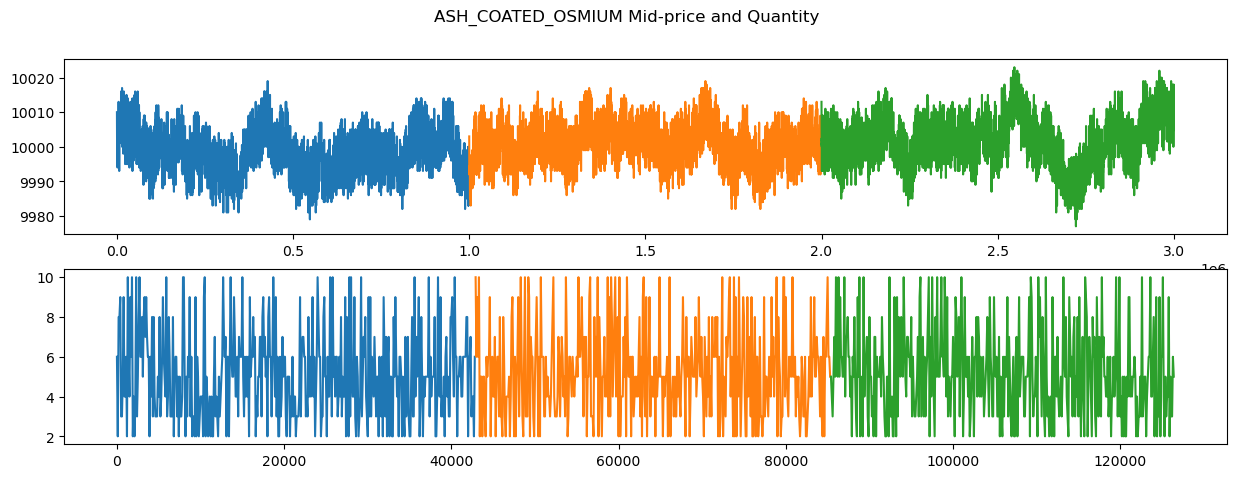

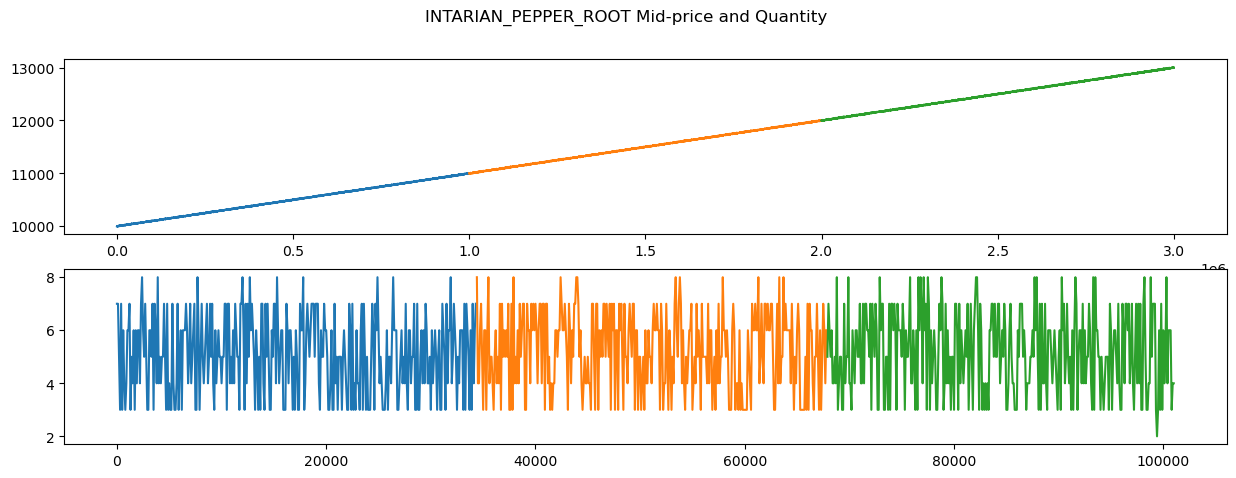

In [3]:
# x1   
product1 = 'ASH_COATED_OSMIUM'
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (15, 5))
fig.suptitle(f'{product1} Mid-price and Quantity')
plot_features(x1_book, 'mid_price', ax[0])
plot_features(x1_market, 'quantity', ax[1])

# x2
product2 = 'INTARIAN_PEPPER_ROOT'
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (15, 5))
fig.suptitle(f'{product2} Mid-price and Quantity')
plot_features(x2_book, 'mid_price', ax[0])
plot_features(x2_market, 'quantity', ax[1])

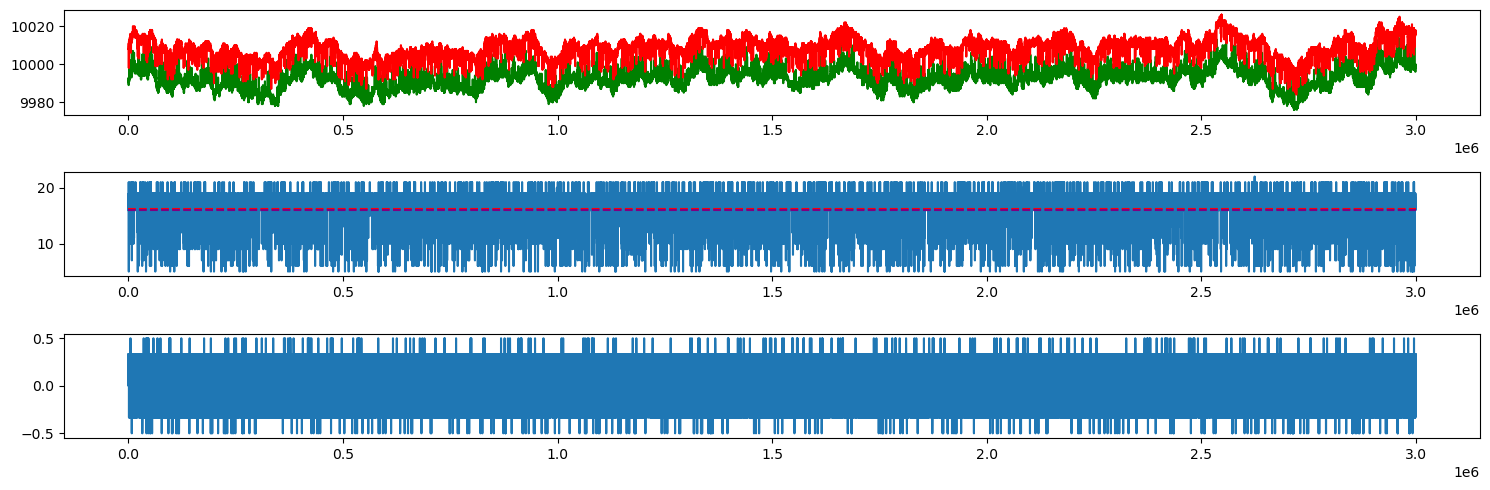

In [4]:
def spread(data: pd.DataFrame): 
    """
    plots spread
    """
    fig, ax = plt.subplots(nrows=3, ncols=1, figsize = (15, 5))
    # spread
    data = data.loc[(data['bid_price_1']!=0) & 
                    (data['ask_price_1']!=0), :]
    best_bid = data['bid_price_1']
    best_ask = data['ask_price_1']
    ax[0].plot(data['timestamp'], data['bid_price_1'], color = 'g')
    ax[0].plot(data['timestamp'], data['ask_price_1'], color = 'r')
    # spread difference
    spread_diff = best_ask - best_bid
    avg_spread = np.mean(spread_diff)
    median_spread = np.median(spread_diff)
    ax[1].plot(data['timestamp'], spread_diff)
    ax[1].hlines(avg_spread, data['timestamp'].values[0], data['timestamp'].values[-1], color = 'r', linestyle = '--') 
    ax[1].hlines(median_spread, data['timestamp'].values[0], data['timestamp'].values[-1], color = 'purple', linestyle = '--') 
    # imbalance
    all_bid_v = data['bid_price_1'] + data['bid_price_2'] + data['bid_price_3']
    all_ask_v = data['ask_price_1'] + data['ask_price_2'] + data['ask_price_3']
    imbalance = (all_ask_v - all_bid_v) / (all_bid_v + all_ask_v)
    ax[2].plot(data['timestamp'], imbalance)

    plt.tight_layout();
spread(x1_book)

## **Model 1 PRODUCT1**

In [5]:
def data_quantiles(data: pd.DataFrame, q_feature: str):
    """
    bins y_label based on quantiles of q_feature 
    """

    book = data.assign(y_label = x1_book['mid_price'].pct_change().fillna(0))

    q_25 = book[q_feature].quantile(q = 0.25)
    q_50 = book[q_feature].quantile(q = 0.50)
    q_75 = book[q_feature].quantile(q = 0.75)

    # subset
    x_q_25 = book.loc[book[q_feature] <= q_25, [q_feature, 'y_label']]
    x_q_50 = book.loc[(book[q_feature] > q_25) & 
                (book[q_feature] <= q_50), [q_feature, 'y_label']]
    x_q_75 = book.loc[(book[q_feature] > q_50) & 
                (book[q_feature] <= q_75), [q_feature, 'y_label']]
    x_q_100 = book.loc[book[q_feature] > q_75, [q_feature, 'y_label']]

    return {
        'data': book,
        'xy_25': x_q_25, 
        'xy_50': x_q_50, 
        'xy_75': x_q_75, 
        'xy_100': x_q_100
    }

# plot
def plot_qs(x_25, x_50, x_75, x_100, q_feature, axis, title = ''):
    """
    plots four quantiles 
    """
    axis.set_title(title)
    axis.scatter(x_25[q_feature].values, x_25['y_label'].values)
    axis.scatter(x_50[q_feature].values, x_50['y_label'].values)
    axis.scatter(x_75[q_feature].values, x_75['y_label'].values)
    axis.scatter(x_100[q_feature].values, x_100['y_label'].values)

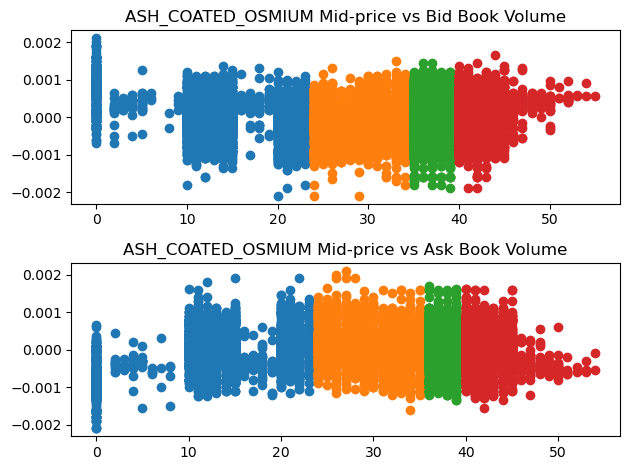

In [6]:
# datasets 
xy_bids = data_quantiles(x1_book, 'total_bid_volume')
xy_asks = data_quantiles(x1_book, 'total_ask_volume')

# plot 
fig, ax = plt.subplots(nrows = 2, ncols = 1)
plot_qs(xy_bids['xy_25'], xy_bids['xy_50'], xy_bids['xy_75'], xy_bids['xy_100'], 'total_bid_volume', ax[0], title = f'{product1} Mid-price vs Bid Book Volume')
plot_qs(xy_asks['xy_25'], xy_asks['xy_50'], xy_asks['xy_75'], xy_asks['xy_100'], 'total_ask_volume', ax[1], title = f'{product1} Mid-price vs Ask Book Volume')
plt.tight_layout();

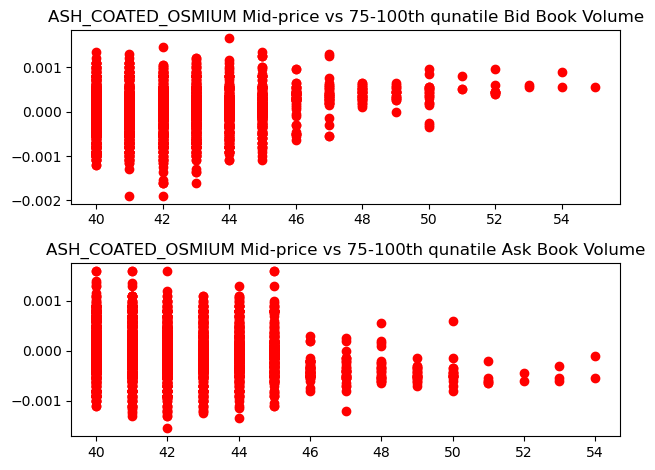

In [7]:
fig, ax = plt.subplots(nrows = 2, ncols=1)
ax[0].set_title(f'{product1} Mid-price vs 75-100th qunatile Bid Book Volume')
ax[0].scatter(xy_bids['xy_100']['total_bid_volume'], xy_bids['xy_100']['y_label'], color = 'r')

ax[1].set_title(f'{product1} Mid-price vs 75-100th qunatile Ask Book Volume')
ax[1].scatter(xy_asks['xy_100']['total_ask_volume'], xy_asks['xy_100']['y_label'], color = 'r')
plt.tight_layout();


In [8]:
# polynomial regression 
def regression_polynomial(data, q_feature, poly: int = 2):
    """
    generlaised polynomial regression 
    """
    x = data[q_feature].values
    X = np.ones((poly, len(x)))
    # polynomial feature vectors 
    for i in range(poly+1):
        X[i:, ] = np.pow(x, i)

    Y = data['y_label'].values
    Xt = X.transpose()
    XXt = X @ Xt
    XXtinv = np.linalg.inv(XXt)
    XtY = X @ Y
    params = XXtinv @ XtY

    return {
        'parameters': params, 
        'data': x,
        'label': Y
    }

def regression_polynomial_predict(data, parameters): 
    """
    predict function for generalised polynomial regression
    """
    slope = parameters[0]
    coeffs = parameters[1:]
    yhat = slope
    for pow, c in enumerate(coeffs): 
        yhat += c*data**(pow+1)

    return yhat

def plot_regression(reg_res, axis, title): 
    """
    plots regression 
    """
    min_x, max_x = min(reg_res['data']), max(reg_res['data'])
    x_sort = np.linspace(min_x, max_x, 100)
    yhat = regression_polynomial_predict(x_sort, reg_res['parameters'])
    # plot
    axis.set_title(title)
    axis.scatter(reg_res['data'], reg_res['label'])
    axis.plot(x_sort, yhat, color = 'r')

### **Model Fit/Predict**

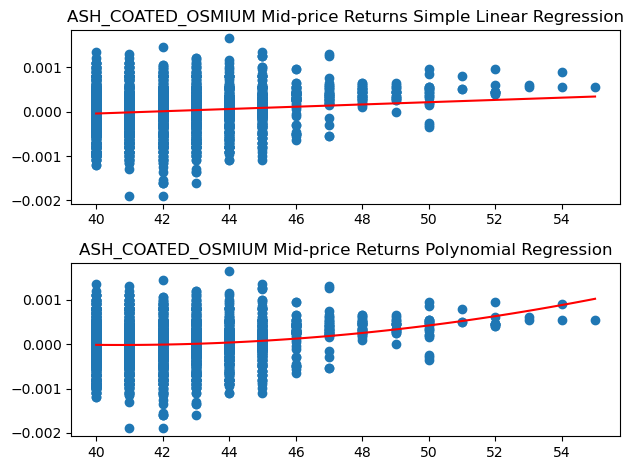

In [9]:
# fit models 
reg_slr = regression_polynomial(xy_bids['xy_100'], 'total_bid_volume', 2)
poly_reg = regression_polynomial(xy_bids['xy_100'], 'total_bid_volume', 3)

# plot
fig, ax = plt.subplots(nrows = 2, ncols = 1)
plot_regression(reg_slr, ax[0], f'{product1} Mid-price Returns Simple Linear Regression')
plot_regression(poly_reg, ax[1], f'{product1} Mid-price Returns Polynomial Regression')
plt.tight_layout()

### **Binning Features**

In [10]:
def bin_data(data, q_feature):
    """
    bins function 
    """
    x = data[q_feature]
    y = data['y_label']
    bins = np.linspace(x.min(), x.max(), 30) 
    bin_indicies = np.digitize(x, bins)

    x_binned = []
    y_binned = []
    for i in range(1, len(bins)):
        mask = bin_indicies == i
        if np.any(mask): 
            x_binned.append(x[mask].mean())
            y_binned.append(y[mask].mean())
    x_binned = np.array(x_binned)
    y_binned = np.array(y_binned)

    xy_bin = pd.DataFrame({
    q_feature: x_binned, 
    'y_label': y_binned
    })

    return xy_bin

xy_bin_bids = bin_data(xy_bids['xy_100'], 'total_bid_volume')
xy_bin_asks = bin_data(xy_asks['xy_100'], 'total_ask_volume')

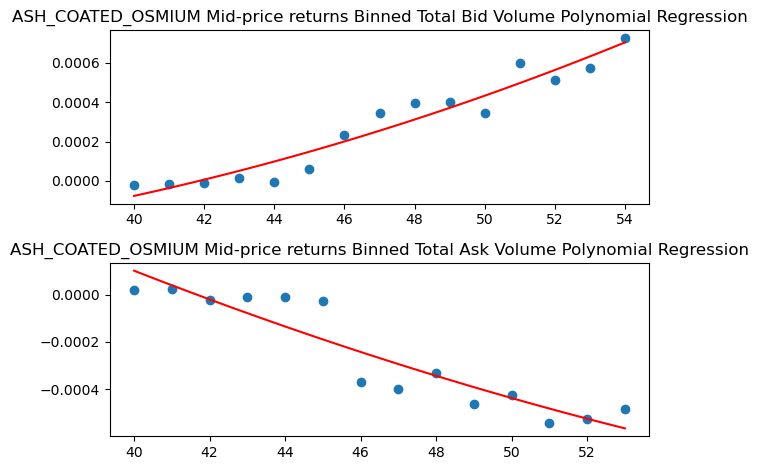

In [11]:
# fit
poly_reg_bins_bid = regression_polynomial(xy_bin_bids, 'total_bid_volume', 3)
poly_reg_bins_ask = regression_polynomial(xy_bin_asks, 'total_ask_volume', 3)

# predict 
yhat_bin_bid = regression_polynomial_predict(poly_reg_bins_bid['data'], poly_reg_bins_bid['parameters'])
yhat_bin_ask = regression_polynomial_predict(poly_reg_bins_ask['data'], poly_reg_bins_ask['parameters'])

# plot 
fig, ax = plt.subplots(nrows = 2, ncols = 1)
plot_regression(poly_reg_bins_bid, ax[0], f'{product1} Mid-price returns Binned Total Bid Volume Polynomial Regression')
plot_regression(poly_reg_bins_ask, ax[1], f'{product1} Mid-price returns Binned Total Ask Volume Polynomial Regression')
plt.tight_layout();

## **Model 1 PRODUCT2**

In [16]:
x2_book

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,total_bid_volume,total_ask_volume,y_label,t
0,0,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,0.0,0.0,0.0,0.0,10005.0,...,10008.0,17.0,0.0,0.0,9998.5,0.0,17.0,26.0,9998.5,0
2,0,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,0.0,0.0,10006.0,...,10008.0,16.0,0.0,0.0,10000.5,0.0,27.0,27.0,10000.5,1
4,0,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,0.0,0.0,0.0,0.0,10008.0,...,0.0,0.0,0.0,0.0,10001.5,0.0,12.0,20.0,10001.5,2
7,0,300,INTARIAN_PEPPER_ROOT,0.0,0.0,0.0,0.0,0.0,0.0,10006.0,...,10008.0,21.0,0.0,0.0,10006.0,0.0,0.0,31.0,10006.0,3
9,0,400,INTARIAN_PEPPER_ROOT,9992.0,20.0,0.0,0.0,0.0,0.0,10006.0,...,10008.0,20.0,0.0,0.0,9999.0,0.0,20.0,32.0,9999.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19991,2,2999500,INTARIAN_PEPPER_ROOT,12989.0,19.0,0.0,0.0,0.0,0.0,13006.0,...,0.0,0.0,0.0,0.0,12997.5,0.0,19.0,12.0,12997.5,29995
19992,2,2999600,INTARIAN_PEPPER_ROOT,12993.0,8.0,0.0,0.0,0.0,0.0,13007.0,...,13010.0,25.0,0.0,0.0,13000.0,0.0,8.0,33.0,13000.0,29996
19995,2,2999700,INTARIAN_PEPPER_ROOT,12989.0,20.0,0.0,0.0,0.0,0.0,13007.0,...,13010.0,20.0,0.0,0.0,12998.0,0.0,20.0,30.0,12998.0,29997
19996,2,2999800,INTARIAN_PEPPER_ROOT,0.0,0.0,0.0,0.0,0.0,0.0,13007.0,...,13010.0,24.0,0.0,0.0,13007.0,0.0,0.0,34.0,13007.0,29998


b0= 9999.987095180166 , b1= 0.10000060034133385


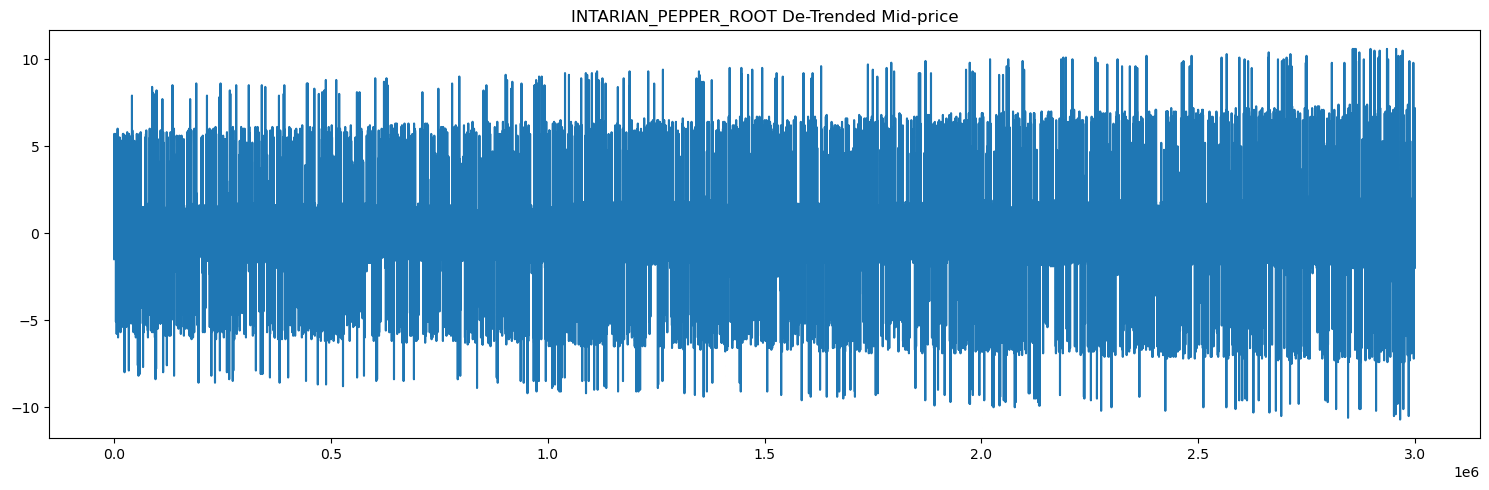

In [18]:
import code_round_1.my_algo_1_2 as my_algo

# de-trend product 2
x2_book = x2_book.assign(
    y_label = x2_book['mid_price'], 
    t = np.arange(0, x2_book.shape[0])
)
de_trend_poly_reg = regression_polynomial(x2_book, 't')
print('b0=', de_trend_poly_reg['parameters'][0], ', b1=', de_trend_poly_reg['parameters'][1])
de_trend_reg = regression_polynomial_predict(x2_book['t'], de_trend_poly_reg['parameters'])
x2_book = x2_book.assign(
    mid_price_de_trend = x2_book['y_label'] - de_trend_reg,
    de_trend_returns  = x2_book['mid_price_de_trend'].pct_change().shift(-1).fillna(0)
)

# plot de-trended series 
fig, ax  = plt.subplots(figsize = (15, 5))
ax.set_title(f'{my_algo.PRODUCT2} De-Trended Mid-price')
ax.plot(x2_book['timestamp'], x2_book['mid_price_de_trend'])
plt.tight_layout();

conditional expetations

In [19]:
n = x2_book.shape[0]
up_outliers = x2_book.loc[x2_book['mid_price_de_trend'] > 6, :]
down_outliers = x2_book.loc[x2_book['mid_price_de_trend'] < -6, :]

# empirical conditional expectations
up_outlier_followed_down_day = len(up_outliers.loc[up_outliers['de_trend_returns']<0])/len(up_outliers)
down_oulier_followed_up_day = len(down_outliers.loc[down_outliers['de_trend_returns']>0])/len(down_outliers)

print('E[down_move_t+1 | up_oulier_t] =', up_outlier_followed_down_day)
print('E[up_move_t+1 | down_outlier_t] =', down_oulier_followed_up_day)

E[down_move_t+1 | up_oulier_t] = 0.9920993227990971
E[up_move_t+1 | down_outlier_t] = 0.026615969581749048


## **Book Probability Measure**

0.30929390199000373 0.3089860198741776


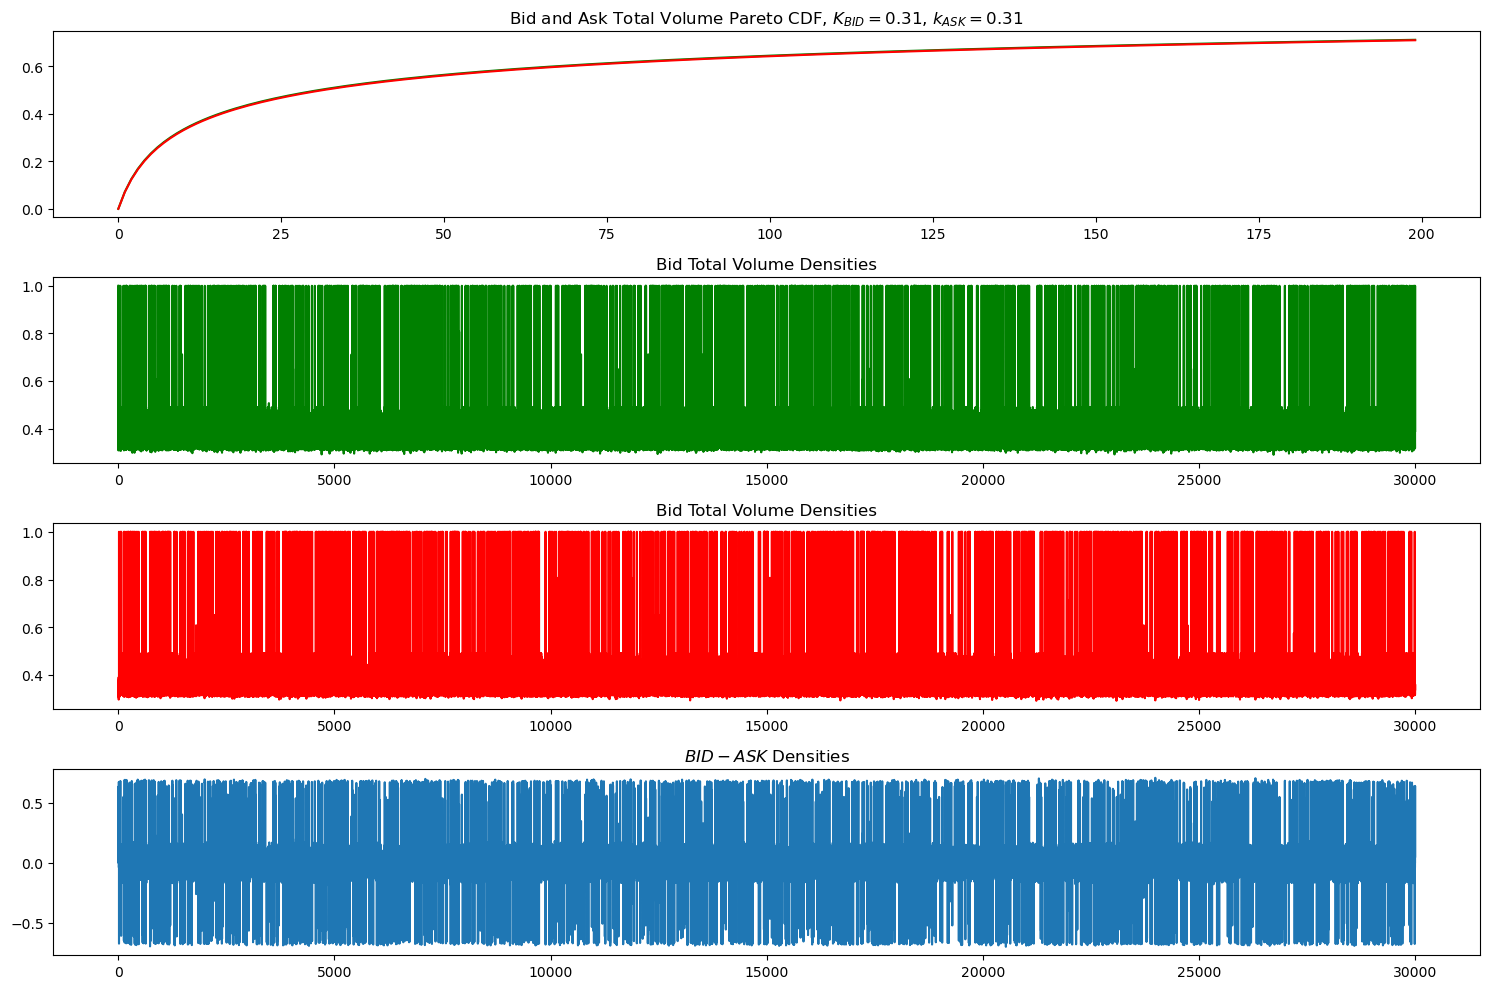

In [35]:
# enforce min values to avoud overflow 
x1_book.loc[x1_book['total_bid_volume'] == 0, 'total_bid_volume'] = 1
x1_book.loc[x1_book['total_ask_volume'] == 0, 'total_ask_volume'] = 1

# compute empirical pareto MLE
x1_book_bid_k = len(x1_book) / np.sum(np.log(x1_book['total_bid_volume']))
x1_book_ask_k = len(x1_book) / np.sum(np.log(x1_book['total_ask_volume']))
print(x1_book_bid_k, x1_book_ask_k)

# cdf for bids and asks 
x1_book_q_bids_sort = np.linspace(min(x1_book['total_bid_volume']), max(x1_book['total_bid_volume']), 200)
x1_book_q_asks_sort = np.linspace(min(x1_book['total_ask_volume']), max(x1_book['total_ask_volume']), 200)

x1_book_bids_comp_cdf = np.pow(1/x1_book_q_bids_sort, x1_book_bid_k)
x1_book_asks_comp_cdf = np.pow(1/x1_book_q_asks_sort, x1_book_ask_k)

# point densities 
x1_book_bid_sf = np.pow(1/x1_book['total_bid_volume'], x1_book_bid_k)
x1_book_ask_sf = np.pow(1/x1_book['total_ask_volume'], x1_book_ask_k)

# dominate side 
book_dom_side = x1_book_bid_sf - x1_book_ask_sf

# plot 
fig, ax = plt.subplots(nrows = 4, ncols = 1, figsize = (15, 10))
ax[0].set_title(r'Bid and Ask Total Volume Pareto CDF, $K_{BID}=0.31$, $k_{ASK}=0.31$')
ax[0].plot(1-x1_book_bids_comp_cdf, color = 'g')
ax[0].plot(1-x1_book_asks_comp_cdf, color = 'r')

ax[1].set_title('Bid Total Volume Densities')
ax[1].plot(x1_book_bid_sf.values, color = 'g')

ax[2].set_title('Bid Total Volume Densities')
ax[2].plot(x1_book_ask_sf.values, color = 'r')

ax[3].set_title(r'$BID - ASK$ Densities')
ax[3].plot(book_dom_side.values)
plt.tight_layout();